In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
from astropy.table import Table
from astropy.io import ascii
import matplotlib.pyplot as plt
from scipy.spatial import Delaunay
import pandas as pd
from itertools import combinations
import networkx as nx
from sklearn.decomposition import PCA
import matplotlib.cm as cm
import itertools
from matplotlib.patches import Circle

In [3]:
filt_n1 = Table.read("/content/drive/MyDrive/DESI/data/LRG_NGC_data_filt1.ecsv").to_pandas()

In [4]:
n_random = 10
rand_ngc1 = {}
for i in range(n_random):
    rand_ngc1[i] = Table.read(f"/content/drive/MyDrive/DESI/rand/LRG_NGC_1_random_{i}_filt.fits").to_pandas()
    rand_ngc1[i]['type'] = 'rand'

In [5]:
void = {}
for j in range(1):
        file = f"/content/drive/MyDrive/DESI/connections_groups/LRG_NGC_1_random_{j}_neighbors_void.parquet"
        df = pd.read_parquet(file)
        void[j] = df

In [6]:
filament = {}
for j in range(1):
        file = f"/content/drive/MyDrive/DESI/connections_groups/LRG_NGC_1_random_{j}_neighbors_filament.parquet"
        df = pd.read_parquet(file)
        filament[j] = df

In [7]:
knot = {}
for j in range(1):
        file = f"/content/drive/MyDrive/DESI/connections_groups/LRG_NGC_1_random_{j}_neighbors_knot.parquet"
        df = pd.read_parquet(file)
        knot[j] = df

In [8]:
def alignment(df):
    if hasattr(df, 'to_pandas'):
        df = df.to_pandas()
    coords = df[['x', 'y', 'z']].values.astype(float)
    pca = PCA(n_components=3)
    coords_rotated = pca.fit_transform(coords)
    return coords_rotated

In [9]:
def new_coords(data):
    new_coords = alignment(data)
    data[['x_rot', 'y_rot', 'z_rot']] = new_coords

In [10]:
new_coords(filt_n1)
new_coords(rand_ngc1[0])

In [11]:
def network(data,group,string_group):
  filt_data = data[['TARGETID', 'x_rot', 'y_rot', 'z_rot']]

  G = nx.Graph()

  edges = zip(group['TARGETID'], group[f'TARGETID_{string_group}'])
  G.add_edges_from(edges)

  componentes = nx.connected_components(G)

  df_grupo_new = {}

  for grupo in componentes:
      grupo_ids = list(grupo)

      group_id = grupo_ids[0]

      df_grupo = filt_data[filt_data['TARGETID'].isin(grupo_ids)].copy()
      df_grupo['id'] = group_id

      df_grupo_new[group_id] = df_grupo

  return df_grupo_new,G

In [12]:
def groups(data,G):
  data_indexed = data.set_index('TARGETID')

  groups = {}

  componentes = list(nx.connected_components(G))

  print(f"Groups: {len(componentes)}")

  for i, comp in enumerate(componentes, start=1):

      ids_en_grupo = [node for node in comp if node in data_indexed.index]
      if len(ids_en_grupo) == 0:
          continue
      df_grupo = data_indexed.loc[ids_en_grupo].copy().reset_index()
      groups[i] = df_grupo
  return groups

In [13]:
def groups_all(data_random,data_real,G):
  data_indexed_random = data_random.set_index('TARGETID')
  data_indexed_real = data_real.set_index('TARGETID')

  groups = {}

  componentes = list(nx.connected_components(G))

  print(f"Groups: {len(componentes)}")

  for i, comp in enumerate(componentes, start=1):

      ids_en_grupo_random = [node for node in comp if node in data_indexed_random.index]
      ids_en_grupo_real = [node for node in comp if node in data_indexed_real.index]

      if len(ids_en_grupo_random) == 0 or len(ids_en_grupo_real) == 0:
          continue

      df_grupo_random = data_indexed_random.loc[ids_en_grupo_random].copy().reset_index()
      df_grupo_real = data_indexed_real.loc[ids_en_grupo_real].copy().reset_index()

      df_final = pd.concat([df_grupo_random, df_grupo_real])
      center = df_final[['x_rot', 'y_rot', 'z_rot']].iloc[0]
      df_final['radio'] = np.sqrt((df_final['x_rot']-center['x_rot'])**2 + (df_final['y_rot']-center['y_rot'])**2 + (df_final['z_rot']-center['z_rot'])**2)
      df_final['log_rad'] = np.log(df_final['radio'].max())

      groups[i] = df_final

  return groups

In [33]:
def groups(data,G):
  data_indexed = data.set_index('TARGETID')

  groups = {}

  componentes = list(nx.connected_components(G))

  print(f"Groups: {len(componentes)}")

  for i, comp in enumerate(componentes, start=1):

      ids_en_grupo = [node for node in comp if node in data_indexed.index]
      if len(ids_en_grupo) == 0:
          continue
      df_grupo = data_indexed.loc[ids_en_grupo].copy().reset_index()
      groups[i] = df_grupo
      centroid = {
                'x': df_grupo['x_rot'].mean(),
                'y': df_grupo['y_rot'].mean(),
                'z': df_grupo['z_rot'].mean()
            }

      df_grupo['radio'] = np.sqrt((df_grupo['x_rot']-centroid['x'])**2 + (df_grupo['y_rot']-centroid['y'])**2 + (df_grupo['z_rot']-centroid['z'])**2)
      df_grupo['log_rad'] = np.log(df_grupo['radio'].max())
      groups[i] = df_grupo

  return groups

In [14]:
def plot_groups(groups, title):
  fig, ax = plt.subplots(figsize=(12, 10))

  for i in groups:
      center = groups[i][['x_rot', 'y_rot', 'z_rot']].iloc[0]
      radio = groups[i]['radio'].max()
      ax.scatter(groups[i]['x_rot'], groups[i]['y_rot'], s=2)
      circle = Circle((center['x_rot'], center['y_rot']), radio, color='gray', fill=False)
      ax.add_patch(circle)

  ax.set_xlabel('PC1', fontsize=14)
  ax.set_ylabel('PC2', fontsize=14)
  ax.set_aspect('equal', adjustable='box')
  ax.grid(True, linestyle='--', linewidth=0.5)
  ax.set_title(f'Groups {title}', fontsize=15)

  plt.tight_layout()

  plt.show()

In [15]:
def plot_hist_log(groups, title):
  fig, ax = plt.subplots(figsize=(8, 5))
  log_list = list()
  for i in groups:
      log = groups[i]['log_rad'].iloc[0]
      log_list.append(log)

  ax.hist(log_list, bins=20, alpha=0.5)
  ax.set_xlabel('Log radius',fontsize=14)
  ax.set_ylabel('Counts',fontsize=14)
  ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)

  fig.suptitle(f'Histograms of log radius {title}', fontsize=20, y=1)

  plt.tight_layout(pad=1.0)
  plt.show()

#With out limits

## Void (Real data conected to random data)

In [29]:
group_void,G_void = network(rand_ngc1[0],void[0],'void')
final_group_void = groups(rand_ngc1[0],G_void)

Groups: 1331


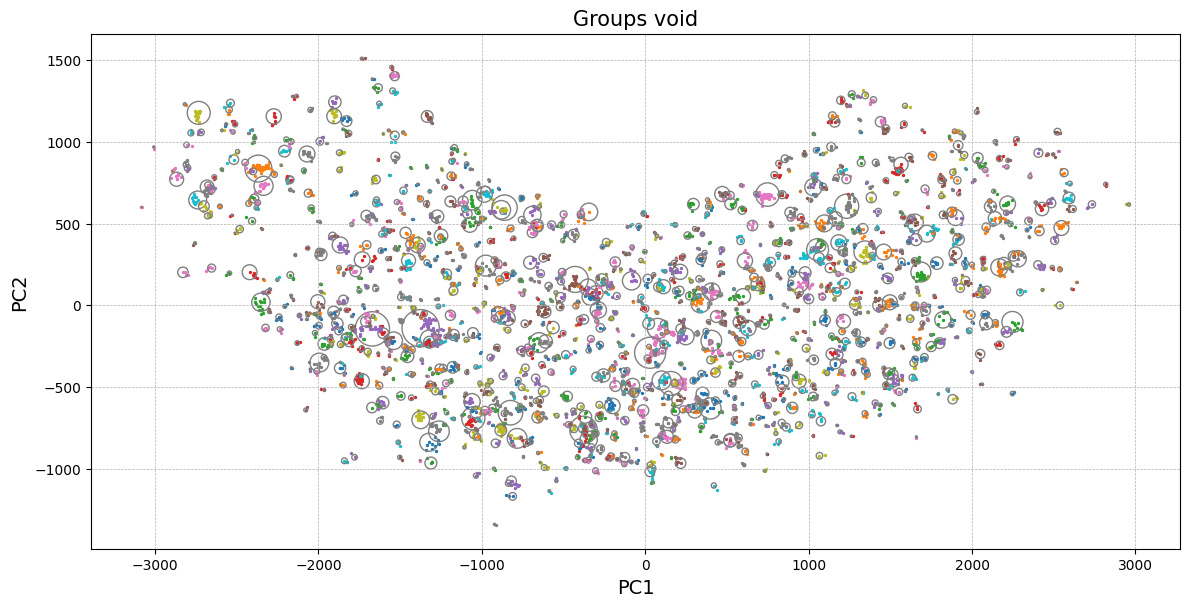

In [31]:
plot_groups(final_group_void,'void')

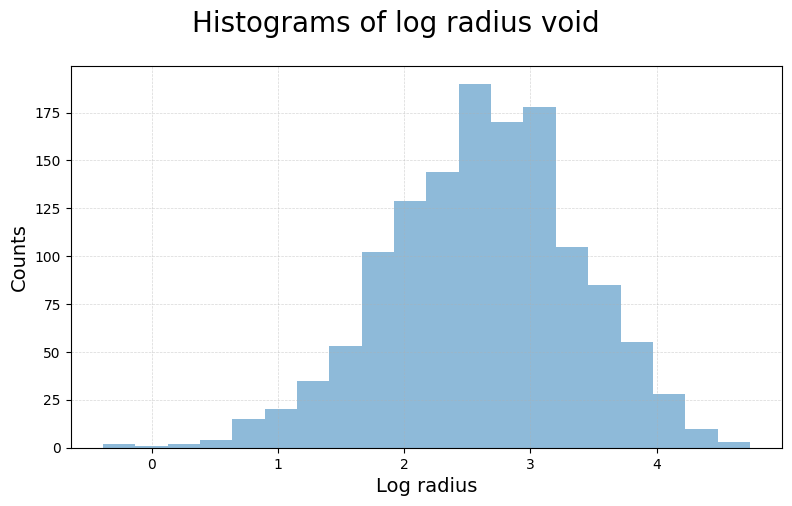

In [32]:
plot_hist_log(final_group_void,'void')

## Knot

In [38]:
group_knot,G_knot = network(filt_n1,knot[0],'knot')
final_group_knot = groups(filt_n1,G_knot)

Groups: 1629


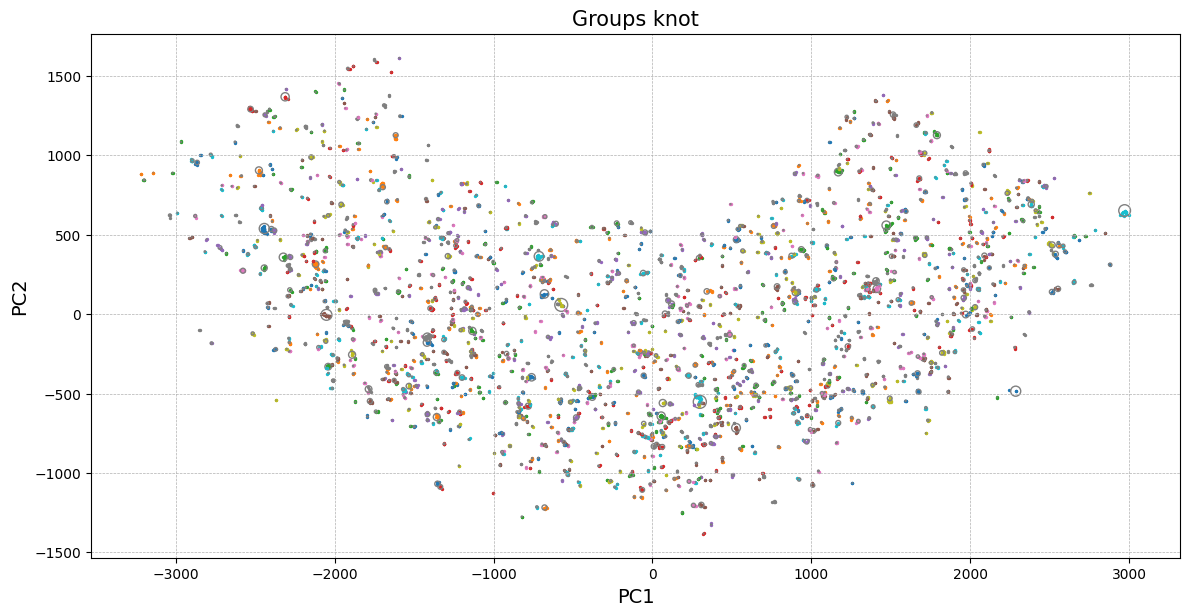

In [39]:
plot_groups(final_group_knot,'knot')

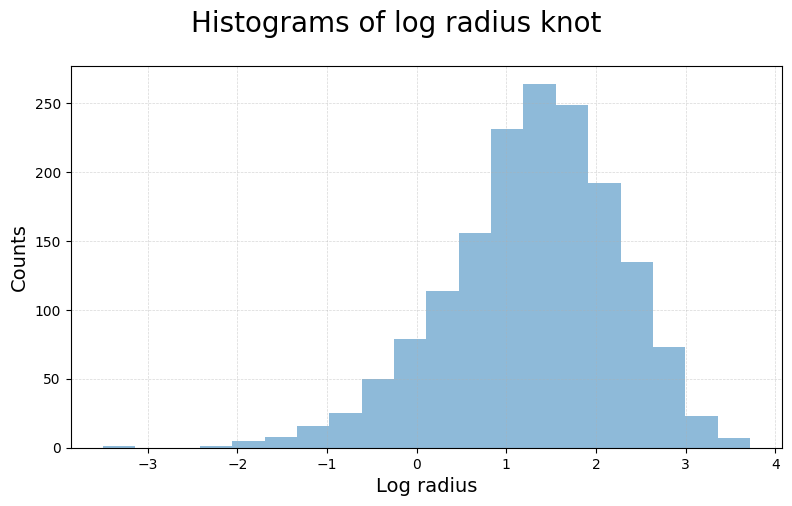

In [40]:
plot_hist_log(final_group_knot,'knot')

# Max neighbours

In [19]:
def network_max(data, group, string_group, max_neighbors=None, max_distance=None):
    filt_data = data[['TARGETID', 'x_rot', 'y_rot', 'z_rot']].copy()

    #merge coords
    group_coords = group.merge(filt_data, on='TARGETID', how='left') \
                        .rename(columns={'x_rot': 'x_src', 'y_rot': 'y_src', 'z_rot': 'z_src'})
    group_coords = group_coords.merge(
        filt_data,
        left_on=f'TARGETID_{string_group}',
        right_on='TARGETID',
        how='left',
        suffixes=('', '_dst')
    ).rename(columns={'x_rot': 'x_dst', 'y_rot': 'y_dst', 'z_rot': 'z_dst'})

    #distance
    group_coords['dist'] = np.sqrt(
        (group_coords['x_src'] - group_coords['x_dst'])**2 +
        (group_coords['y_src'] - group_coords['y_dst'])**2 +
        (group_coords['z_src'] - group_coords['z_dst'])**2
    )

    #max_distance
    if max_distance is not None:
        group_coords = group_coords[group_coords['dist'] <= max_distance]

    #max_neighbors
    if max_neighbors is not None:
        group_coords = (group_coords
                        .sort_values(['TARGETID', 'dist'])
                        .groupby('TARGETID', group_keys=False)
                        .head(max_neighbors))
    G = nx.Graph()
    G.add_edges_from(zip(group_coords['TARGETID'], group_coords[f'TARGETID_{string_group}']))

    componentes = list(nx.connected_components(G))
    print(f"Components: {len(componentes)} with max_neighbors={max_neighbors}, max_distance={max_distance}")

    df_grupo_new = {}
    for comp in componentes:
        ids = list(comp)
        gid = ids[0]
        df = filt_data[filt_data['TARGETID'].isin(ids)].copy()
        df['id'] = gid
        df_grupo_new[gid] = df

    return df_grupo_new, G

In [20]:
def groups_max(data,G):
  data_indexed = data.set_index('TARGETID')

  groups = {}

  componentes = list(nx.connected_components(G))

  print(f"Groups: {len(componentes)}")

  for i, comp in enumerate(componentes, start=1):

      ids_en_grupo = [node for node in comp if node in data_indexed.index]
      if len(ids_en_grupo) == 0:
          continue
      df_grupo = data_indexed.loc[ids_en_grupo].copy().reset_index()
      groups[i] = df_grupo
      centroid = {
                'x': df_grupo['x_rot'].mean(),
                'y': df_grupo['y_rot'].mean(),
                'z': df_grupo['z_rot'].mean()
            }

      df_grupo['radio'] = np.sqrt((df_grupo['x_rot']-centroid['x'])**2 + (df_grupo['y_rot']-centroid['y'])**2 + (df_grupo['z_rot']-centroid['z'])**2)
      df_grupo['log_rad'] = np.log(df_grupo['radio'].max())
      groups[i] = df_grupo

  return groups

In [21]:
def plot_top_groups_max(groups, title, top_n=10):
    sorted_groups = sorted(groups.items(), key=lambda item: len(item[1]), reverse=True)
    top_groups = sorted_groups[:top_n]

    fig, ax = plt.subplots(figsize=(10, 8))
    colors = itertools.cycle(plt.cm.tab10.colors)

    for group_id, df_grupo in top_groups:
        center = {
            'x': df_grupo['x_rot'].mean(),
            'y': df_grupo['y_rot'].mean(),
            'z': df_grupo['z_rot'].mean()
        }
        radio = df_grupo['radio'].max()
        circle = Circle((center['x'], center['y']), radio, color='gray', fill=False)
        ax.add_patch(circle)
        ax.scatter(
            df_grupo['x_rot'],
            df_grupo['y_rot'],
            s=6,
            color=next(colors),
            label=f'Grupo {group_id} (n={len(df_grupo)})'
        )

    ax.set_xlabel('PC1', fontsize=14)
    ax.set_ylabel('PC2', fontsize=14)
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, linestyle='--', linewidth=0.5)
    ax.set_title(f'Top {top_n} bigger sizes - {title}', fontsize=15)
    ax.legend(markerscale=2, fontsize=8, loc='lower right', ncol=2)
    plt.tight_layout()
    plt.show()

## Filament real data

In [34]:
%%time
group_filament_max, G_filament_max = network_max(
    data=filt_n1,
    group=filament[0],
    string_group='filament',
    max_neighbors=20,
    max_distance=21
)

Components: 14558 with max_neighbors=20, max_distance=21
CPU times: user 3min 56s, sys: 1.27 s, total: 3min 57s
Wall time: 4min 11s


In [35]:
%%time
final_group_filament_max = groups(filt_n1,G_filament_max)

Groups: 14558
CPU times: user 38.2 s, sys: 1.19 s, total: 39.4 s
Wall time: 40.1 s


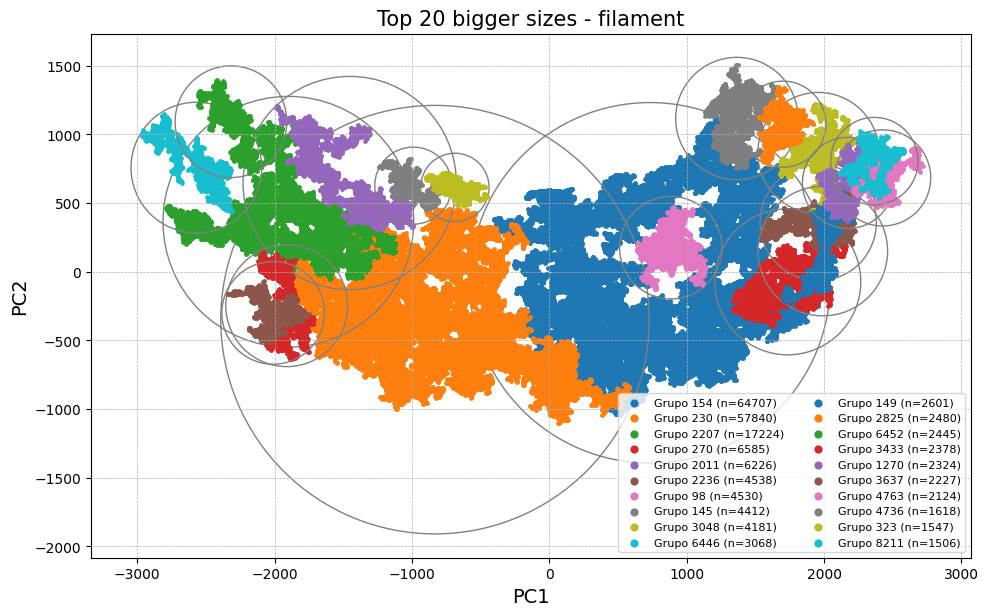

In [36]:
plot_top_groups_max(final_group_filament_max,'filament',top_n=20)

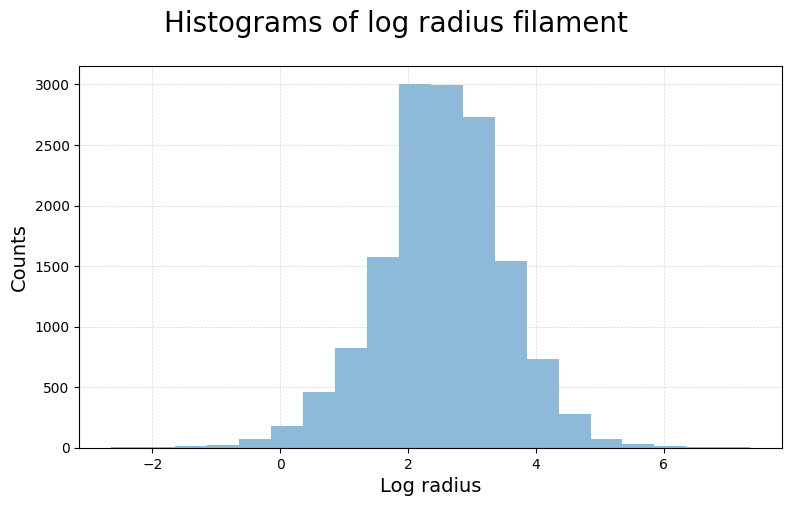

In [37]:
plot_hist_log(final_group_filament_max,'filament')